In [2]:
import numpy as np
import pandas as pd
import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 


In [15]:
df = pd.read_csv('../data/Amazon_employee_access.csv')
df.head()

,id,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE,target
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908,1
1,2,17183,1540,117961,118343,123125,118536,118536,308574,118539,1
2,3,36724,14457,118219,118220,117884,117879,267952,19721,117880,1
3,4,36135,5396,117961,118343,119993,118321,240983,290919,118322,1
4,5,42680,5905,117929,117930,119569,119323,123932,19793,119325,1


In [16]:
unique_ids = df['id'].nunique()
total_ids = len(df)

print(f"tous les id {total_ids} -- id unique {unique_ids}")

tous les id 32769 -- id unique 32769


In [4]:
from sklearn.metrics import accuracy_score, precision_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') 
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision,confusion_mx

In [5]:
X = df.drop(columns=["target"])  
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression()
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)

In [7]:
logreg_accuracy, logreg_precision,logreg_confusion_mx = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
nb_accuracy, nb_precision,nb_confusion_mx = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
rf_accuracy, rf_precision,rf_confusion_mx = evaluate_classifier(rf, X_train, y_train, X_test, y_test)

print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}, Precision: {logreg_precision:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}, Precision: {nb_precision:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}\n\n")

print(f"Logistic Regression Confusion Matrix:\n{logreg_confusion_mx}")
print(f"Naive Bayes Confusion Matrix:\n{nb_confusion_mx}")
print(f"Random Forest Confusion Matrix:\n{rf_confusion_mx}")

Logistic Regression Accuracy: 0.9437, Precision: 0.9437
Naive Bayes Accuracy: 0.9135, Precision: 0.9446
Random Forest Accuracy: 0.9504, Precision: 0.9578


Logistic Regression Confusion Matrix:
[[   0  369]
 [   0 6185]]
Naive Bayes Confusion Matrix:
[[  19  350]
 [ 217 5968]]
Random Forest Confusion Matrix:
[[  99  270]
 [  55 6130]]


In [8]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x000,x001,x002,x003,x004,x005,x006,x007,x008,x009,...,Abs(x009)/x001,x002*Abs(x004),exp(x008)/x005,exp(x008)/x004,x001**3*Abs(x000),x007**3*Abs(x008),Abs(x002)*Abs(x008),x007/x005,Abs(x007)/x003,x006*Abs(x007)
0,-0.835977,-0.233337,-0.488650,0.09272,0.005532,0.000855,-0.244721,-0.752030,1.066961,-0.253697,...,-1.087255,-0.002703,3397.693466,525.448824,-0.010621,-0.453788,0.521370,-879.111054,8.110715,-0.184037
1,1.525435,-0.554055,-0.577412,0.09272,0.009047,0.036138,-0.208891,-0.525007,-0.649631,-0.061276,...,-0.110595,-0.005224,14.451092,57.726080,-0.259449,-0.094007,0.375105,-14.527694,5.662250,-0.109669
2,-1.485476,-0.717808,-0.700605,0.09272,-0.000401,0.253479,-0.229803,1.018649,1.066961,-0.173478,...,-0.241678,-0.000281,11.466574,-7256.177108,-0.549402,1.127773,0.747518,4.018673,10.986229,-0.234088
3,1.699544,0.963033,-0.571511,0.09272,-0.016879,-0.026886,-0.244721,-0.744232,1.066961,-0.253697,...,0.263435,-0.009646,-108.107203,-172.202546,1.517945,-0.439818,0.609780,27.681369,8.026617,-0.182129
4,0.432788,-1.119261,-0.250921,0.09272,-0.000401,0.014146,-0.258125,-0.752030,1.066961,-0.325271,...,-0.290613,-0.000101,205.468879,-7256.177108,-0.606833,-0.453788,0.267723,-53.162525,8.110715,-0.194117


In [9]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")


Nombre de nouvelles features créées : 37


In [10]:
acc_logreg_af, prec_logreg_af,confusion_mx_logreg_af = evaluate_classifier(logreg, X_train_af, y_train, X_test_af, y_test)
acc_nb_af, prec_nb_af,confusion_mx_nb_af = evaluate_classifier(nb, X_train_af, y_train, X_test_af, y_test)
acc_rf_af, prec_rf_af,confusion_mx_rf_af = evaluate_classifier(rf, X_train_af, y_train, X_test_af, y_test)

print(f"Logistic Regression Accuracy with AutoFeat: {acc_logreg_af:.2f}, Precision: {prec_logreg_af:.2f}")
print(f"Naive Bayes Accuracy with AutoFeat: {acc_nb_af:.2f}, Precision: {prec_nb_af:.2f}")
print(f"Random Forest Accuracy with AutoFeat: {acc_rf_af:.2f}, Precision: {prec_rf_af:.2f}\n\n")

print(f"Logistic Regression Confusion Matrix with AutoFeat:\n{confusion_mx_logreg_af}")
print(f"Naive Bayes Confusion Matrix with AutoFeat:\n{confusion_mx_nb_af}")
print(f"Random Forest Confusion Matrix with AutoFeat:\n{confusion_mx_rf_af}")

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy with AutoFeat: 0.92, Precision: 0.94
Naive Bayes Accuracy with AutoFeat: 0.92, Precision: 0.95
Random Forest Accuracy with AutoFeat: 0.95, Precision: 0.96


Logistic Regression Confusion Matrix with AutoFeat:
[[  17  352]
 [ 189 5996]]
Naive Bayes Confusion Matrix with AutoFeat:
[[  18  351]
 [ 147 6038]]
Random Forest Confusion Matrix with AutoFeat:
[[ 117  252]
 [  62 6123]]


In [17]:
import featuretools as ft

es = ft.EntitySet(id = 'ac')

es.add_dataframe(dataframe_name = 'amazonaccess', dataframe = df, index = 'id')

es.normalize_dataframe(base_dataframe_name='amazonaccess', new_dataframe_name='manager', index = 'MGR_ID')
es.normalize_dataframe(base_dataframe_name='amazonaccess', new_dataframe_name='role', index = 'ROLE_CODE',
     additional_columns = ['ROLE_TITLE', 'ROLE_DEPTNAME', 'ROLE_FAMILY', 'ROLE_FAMILY_DESC','ROLE_ROLLUP_1','ROLE_ROLLUP_2']
     )


Entityset: ac
  DataFrames:
    amazonaccess [Rows: 32769, Columns: 5]
    manager [Rows: 4243, Columns: 1]
    role [Rows: 343, Columns: 7]
  Relationships:
    amazonaccess.MGR_ID -> manager.MGR_ID
    amazonaccess.ROLE_CODE -> role.ROLE_CODE

In [18]:
feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'amazonaccess', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)
feature_matrix.head()

Built 36 features
Elapsed: 00:00 | Progress:  28%|██▊       

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function sum at 0x000001FE1DDC5240> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x000001FE1DDC5990> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x000001FE1DDC6170> is currently using SeriesGr

Elapsed: 00:01 | Progress: 100%|██████████


,RESOURCE,MGR_ID,ROLE_CODE,target,role.ROLE_TITLE,role.ROLE_DEPTNAME,role.ROLE_FAMILY,role.ROLE_FAMILY_DESC,role.ROLE_ROLLUP_1,role.ROLE_ROLLUP_2,...,role.MEAN(amazonaccess.RESOURCE),role.MEAN(amazonaccess.target),role.MIN(amazonaccess.RESOURCE),role.MIN(amazonaccess.target),role.SKEW(amazonaccess.RESOURCE),role.SKEW(amazonaccess.target),role.STD(amazonaccess.RESOURCE),role.STD(amazonaccess.target),role.SUM(amazonaccess.RESOURCE),role.SUM(amazonaccess.target)
id,,,,,,,,,,,,,,,,,,,,,
1,39353,85475,117908,1,117905,123472,290919,117906,117961,118300,...,43795.974323,0.967625,0.0,0.0,1.757304,-5.286283,33628.843470,0.177019,156920976.0,3467.0
2,17183,1540,118539,1,118536,123125,308574,118536,117961,118343,...,45752.222222,0.962963,153.0,0.0,2.702576,-4.995900,41985.627674,0.190029,3705930.0,78.0
3,36724,14457,117880,1,117879,117884,19721,267952,118219,118220,...,37313.847930,0.889331,256.0,0.0,2.154026,-2.484986,22999.576497,0.313847,46866193.0,1117.0
4,36135,5396,118322,1,118321,119993,290919,240983,117961,118343,...,43788.879759,0.920413,0.0,0.0,1.980341,-3.107662,32964.401102,0.270682,203574502.0,4279.0
5,42680,5905,119325,1,119323,119569,19793,123932,117929,117930,...,38904.986667,0.866667,391.0,0.0,5.417272,-2.201556,37555.382944,0.342224,2917874.0,65.0


In [22]:
print(f"Nouvelles colonnes {feature_matrix.shape[1]-df.shape[1]}")
print(feature_matrix.isna().sum())

Nouvelles colonnes 25
RESOURCE                                  0
MGR_ID                                    0
ROLE_CODE                                 0
target                                    0
role.ROLE_TITLE                           0
role.ROLE_DEPTNAME                        0
role.ROLE_FAMILY                          0
role.ROLE_FAMILY_DESC                     0
role.ROLE_ROLLUP_1                        0
role.ROLE_ROLLUP_2                        0
manager.COUNT(amazonaccess)               0
manager.MAX(amazonaccess.RESOURCE)        0
manager.MAX(amazonaccess.target)          0
manager.MEAN(amazonaccess.RESOURCE)       0
manager.MEAN(amazonaccess.target)         0
manager.MIN(amazonaccess.RESOURCE)        0
manager.MIN(amazonaccess.target)          0
manager.SKEW(amazonaccess.RESOURCE)    2059
manager.SKEW(amazonaccess.target)      2059
manager.STD(amazonaccess.RESOURCE)      845
manager.STD(amazonaccess.target)        845
manager.SUM(amazonaccess.RESOURCE)        0
manager.SU

In [25]:
cleaned_feature_matrix = feature_matrix.dropna()
X = cleaned_feature_matrix.drop(columns=["target"])  
y = cleaned_feature_matrix["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

acc_logreg_ft, prec_logreg_ft,confusion_mx_logreg_ft = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
acc_nb_ft, prec_nb_ft,confusion_mx_nb_ft = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
acc_rf_ft, prec_rf_ft,confusion_mx_rf_ft = evaluate_classifier(rf, X_train, y_train, X_test, y_test)

print(f"Logistic Regression Accuracy with featuretools: {acc_logreg_ft:.2f}, Precision: {prec_logreg_ft:.2f}")
print(f"Naive Bayes Accuracy with featuretools: {acc_nb_ft:.2f}, Precision: {prec_nb_ft:.2f}")
print(f"Random Forest Accuracy with featuretools: {acc_rf_ft:.2f}, Precision: {prec_rf_ft:.2f}\n\n")

print(f"Logistic Regression Confusion Matrix with featuretools:\n{confusion_mx_logreg_ft}")
print(f"Naive Bayes Confusion Matrix with featuretools:\n{confusion_mx_nb_ft}")
print(f"Random Forest Confusion Matrix with featuretools:\n{confusion_mx_rf_ft}")

Logistic Regression Accuracy with featuretools: 0.95, Precision: 0.96
Naive Bayes Accuracy with featuretools: 0.76, Precision: 1.00
Random Forest Accuracy with featuretools: 0.94, Precision: 0.97


Logistic Regression Confusion Matrix with featuretools:
[[  88  237]
 [  57 5753]]
Naive Bayes Confusion Matrix with featuretools:
[[ 318    7]
 [1484 4326]]
Random Forest Confusion Matrix with featuretools:
[[ 137  188]
 [ 186 5624]]


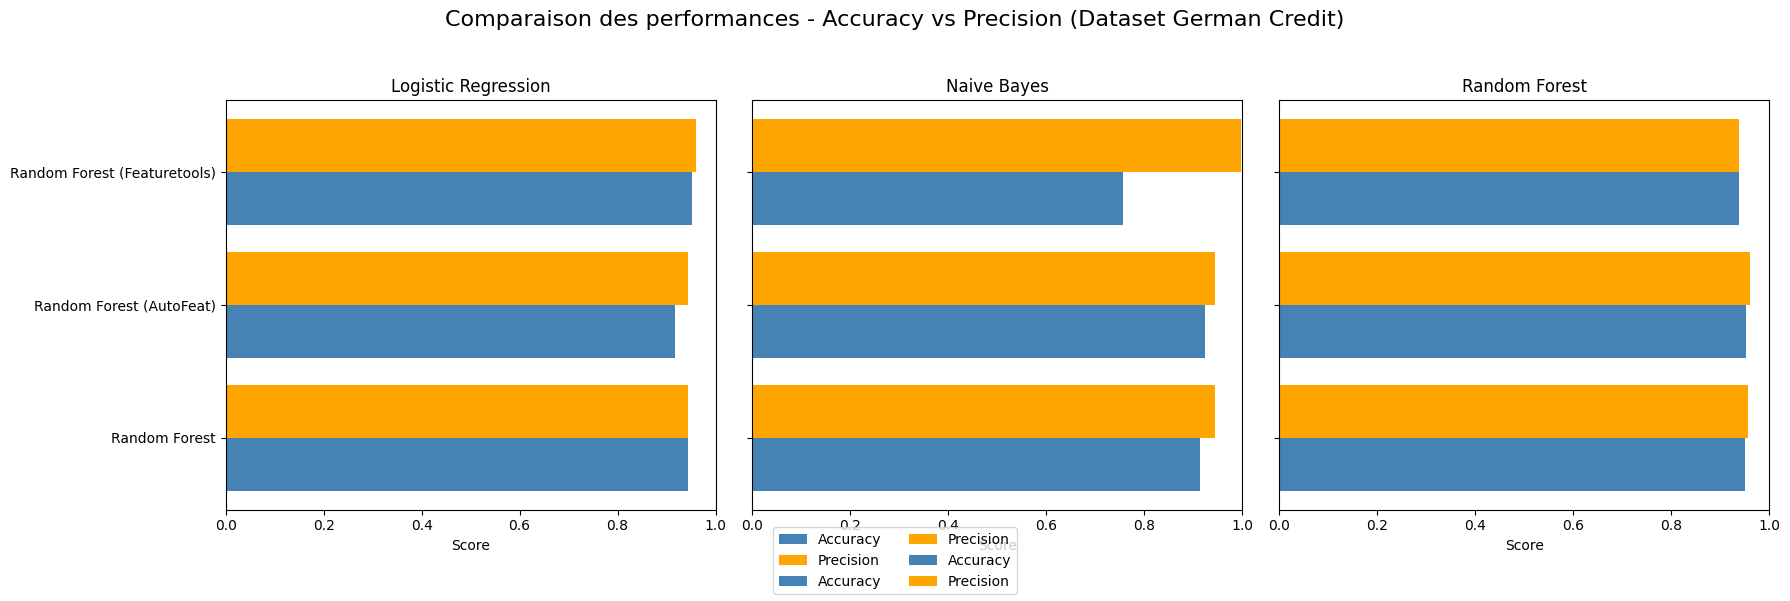

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Organisation des données par modèle
model_groups = {
    "Logistic Regression": {
        "labels": ["Logistic Reg.", "LogReg (AutoFeat)","LogReg (Featuretools)"],
        "accuracy": [logreg_accuracy, acc_logreg_af,acc_logreg_ft],
        "precision": [logreg_precision, prec_logreg_af,prec_logreg_ft]
    },
    "Naive Bayes": {
        "labels": ["Naive Bayes", "Naive Bayes (AutoFeat)","Naive Bayes (Featuretools)"],
        "accuracy": [nb_accuracy, acc_nb_af,acc_nb_ft],
        "precision": [nb_precision, prec_nb_af,prec_nb_ft]
    },
    "Random Forest": {
        "labels": ["Random Forest", "Random Forest (AutoFeat)", "Random Forest (Featuretools)"],
        "accuracy": [rf_accuracy, acc_rf_af,acc_rf_ft],
        "precision": [rf_precision, prec_rf_af,acc_rf_ft]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_name, data) in enumerate(model_groups.items()):
    ax = axes[i]
    y = np.arange(len(data["labels"]))
    bar_height = 0.4

    # Accuracy (bleu)
    ax.barh(y - bar_height/2, data["accuracy"], height=bar_height, color='steelblue', label='Accuracy')
    # Precision (orange)
    ax.barh(y + bar_height/2, data["precision"], height=bar_height, color='orange', label='Precision')

    ax.set_yticks(y)
    ax.set_yticklabels(data["labels"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_title(model_name)

fig.suptitle("Comparaison des performances - Accuracy vs Precision (Dataset German Credit)", fontsize=16)
fig.legend(loc="lower center", ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
